In [10]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import warnings
warnings.filterwarnings("ignore")

pylab.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,   
    'axes.titlesize': 7,      
    'axes.labelsize': 7,             
    'xtick.labelsize': 7,        
    'ytick.labelsize': 7,          
    'legend.fontsize': 7,           
    'figure.titlesize': 7,        
})
pylab.rcParams['pdf.fonttype'] = 42
pylab.rcParams['ps.fonttype'] = 42
plt.rcParams['figure.dpi'] = 200

Fig. 2a

In [6]:
# Define complement dictionary
complement_dic = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
# Load data
mutation_asymmetry_dics = json.load(open('./data/mut_asym.extend_3000.binsize_100.json', 'r'))

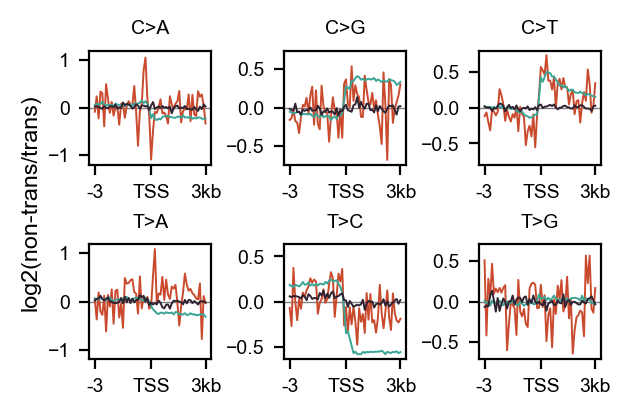

In [8]:
# Plot
fig, axes = plt.subplots(2, 3, figsize=(3.3, 2))
axes = axes.flatten()

for fig_idx, target_mut in enumerate([
    "C>A", "C>G", "C>T", 
    "T>A", "T>C", "T>G",
]):

    target_mut_comp = f"{complement_dic[target_mut[0]]}>{complement_dic[target_mut[-1]]}"

    for idx, gene_group in enumerate([
        "RDH",
        "Exp",
        "Unexp"
    ]):

        density1 = np.array(mutation_asymmetry_dics[gene_group][target_mut]['variant count']) / (np.array(mutation_asymmetry_dics[gene_group][target_mut]['site count']) - np.array(mutation_asymmetry_dics[gene_group][target_mut]['mask count']))
        density2 = np.array(mutation_asymmetry_dics[gene_group][target_mut_comp]['variant count']) / (np.array(mutation_asymmetry_dics[gene_group][target_mut_comp]['site count']) - np.array(mutation_asymmetry_dics[gene_group][target_mut_comp]['mask count']))

        y_values1 = -np.log(1-density1)
        y_values2 = -np.log(1-density2)
        y_ratio = np.log2(y_values1 / y_values2)

        axes[fig_idx].plot(
            range(len(y_values2)), y_ratio, color=["#CA4A2E", "#3BA595", "#302331"][idx],
            linewidth=0.7, label=gene_group,
        )

        xticks_positions = [0, len(y_values1) // 2, len(y_values1) - 1]
        xticks_labels = ['-3', 'TSS', '3kb']

        axes[fig_idx].set_xticks(xticks_positions)
        axes[fig_idx].set_xticklabels(xticks_labels)
        axes[fig_idx].set_title(f"{target_mut}")

handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    ylim = ax.get_ylim()
    max_y_abs = max(abs(ylim[0]), abs(ylim[1]))
    ax.set_ylim(-max_y_abs, max_y_abs)
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, zorder=-5)

fig.supylabel("log2(non-trans/trans)")

fig.subplots_adjust(
    wspace=0.6,
    hspace=0.7
)

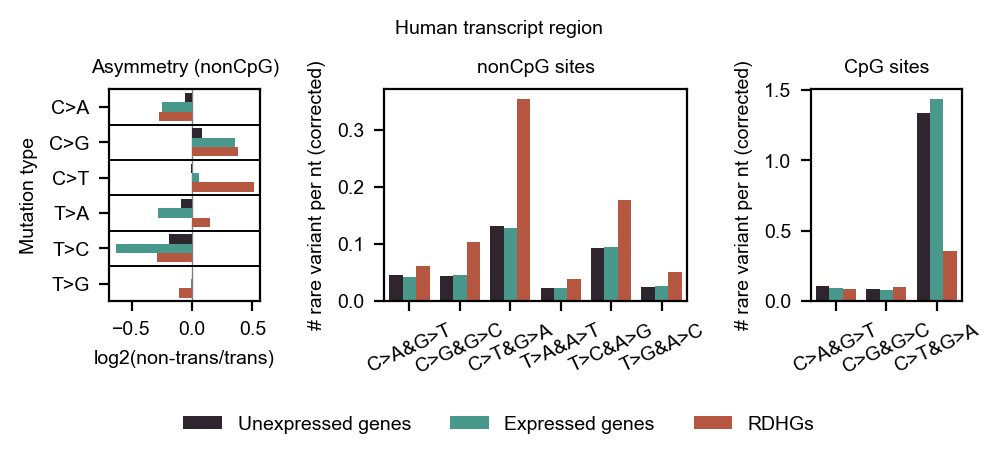

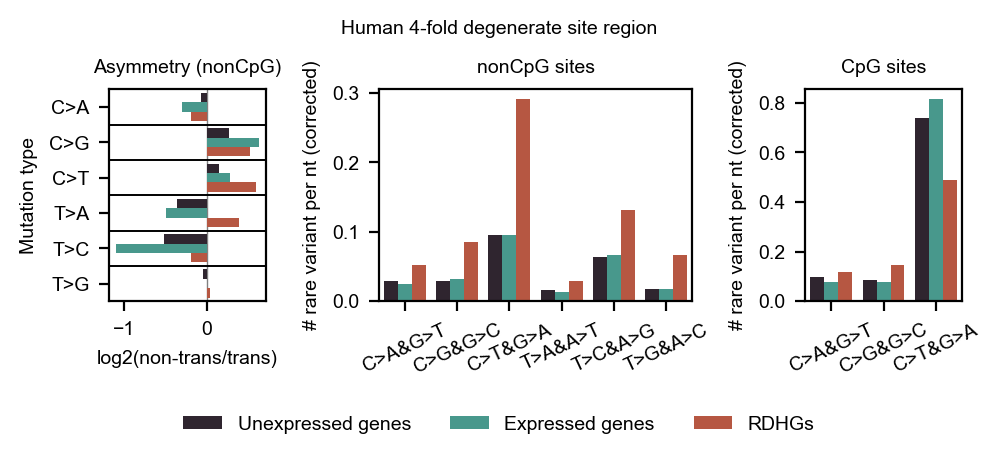

In [11]:
asym_result_df = pd.read_csv('./data/human_mutation_asymmetry_score.csv')
mr_result_df = pd.read_csv('./data/human_mutation_density.csv')
using_region_lst = ['transcript', '4dsite']
using_species_lst = ['human']

for using_species in using_species_lst:
    for using_region in using_region_lst:
        asym_result_df_filter = (asym_result_df['region'] == using_region) & (asym_result_df['species'] == using_species)
        mr_result_df_filter = (mr_result_df['region'] == using_region) & (mr_result_df['species'] == using_species)
        # Color mapping
        color_mapping = {
            'RDHGs': '#CA4A2E', 
            'Expressed genes': '#3BA595',  
            'Unexpressed genes': '#302331' 
        }

        # Plot
        fig, axes = plt.subplots(1, 3, figsize=(5, 1.8), width_ratios=[3, 6, 3])
        asym_result_df['mutation'] = asym_result_df['mutation'].str.split('/').str[0]
        # Asymmetry
        sns.barplot(
            data=asym_result_df[asym_result_df_filter],
            y='mutation',
            x='asymmetry score log',
            hue='gene group',
            hue_order=[
                'Unexpressed genes', 'Expressed genes', 'RDHGs'
            ],
            ax=axes[0],
            palette=color_mapping,
        )
        for i in range(0, 5):
            axes[0].axhline(i+0.5, color='black', linewidth=0.7)

        # 1-mer mutation density
        mr_result_df_noncpg = mr_result_df[
            ~mr_result_df['mutation'].str.contains('CpG')
        ]
        sns.barplot(
            data=mr_result_df_noncpg[mr_result_df_filter],
            x='mutation',
            y='density',
            hue='gene group',
            hue_order=[
                'Unexpressed genes', 'Expressed genes', 'RDHGs'
            ],
            ax=axes[1],
            palette=color_mapping,
        )
        mr_result_df_cpg = mr_result_df[
            mr_result_df['mutation'].str.contains('CpG')
        ]
        mr_result_df_cpg['mutation'] = mr_result_df_cpg['mutation'].str.replace('(CpG)', '')
        sns.barplot(
            data=mr_result_df_cpg[mr_result_df_filter],
            x='mutation',
            y='density',
            hue='gene group',
            hue_order=[
                'Unexpressed genes', 'Expressed genes', 'RDHGs'
            ],
            ax=axes[2],
            palette=color_mapping,
        )

        # Adjust figure
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=4, frameon=False)
        for ax in axes:
            # Remove legend
            ax.legend_.remove()

        axes[0].set_ylabel('Mutation type')
        axes[0].set_xlabel('log2(non-trans/trans)')
        axes[0].set_title('Asymmetry (nonCpG)')
        axes[0].axvline(0, color='gray', linewidth=0.5, zorder=0)
        for ax in axes[1:]:
            ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='center')
            ax.set_ylabel('# rare variant per nt (corrected)')
            ax.set_xlabel('')
        axes[1].set_title('nonCpG sites')
        axes[2].set_title('CpG sites')

        plt.tight_layout()
        fig.suptitle(f'{using_species.capitalize()} {using_region.replace("4dsite", "4-fold degenerate site")} region', y=1.05)